In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_transforms():
    """
    Training transforms include augmentation.
    Validation/test transforms only resize and normalize.
    """
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3
        ),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    return train_transforms, val_transforms

In [3]:
def get_dataloaders(data_dir, batch_size=32):
    train_tf, val_tf = get_transforms()

    # Load full dataset with training transforms initially
    full_dataset = datasets.ImageFolder(data_dir, transform=train_tf)

    # Store class names before splitting
    class_names = full_dataset.classes

    # Split 80/10/10
    total = len(full_dataset)
    train_size = int(0.8 * total)
    val_size = int(0.1 * total)
    test_size = total - train_size - val_size

    print(f"Train size: {train_size}")
    print(f"Val size:   {val_size}")
    print(f"Test size:  {test_size}")

    # Random split with fixed seed for reproducibility
    train_set, val_set, test_set = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Override transforms for val and test
    val_set.dataset.transform = val_tf
    test_set.dataset.transform = val_tf

    # Create DataLoaders
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader, class_names

In [4]:
dataset_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
train_loader, val_loader, test_loader, class_names = get_dataloaders(dataset_path)

print(f"\nTotal classes: {len(class_names)}")
print(f"Batches in train_loader: {len(train_loader)}")
print(f"Batches in val_loader:   {len(val_loader)}")
print(f"Batches in test_loader:  {len(test_loader)}")

Train size: 43444
Val size:   5430
Test size:  5431

Total classes: 38
Batches in train_loader: 1358
Batches in val_loader:   170
Batches in test_loader:  170


In [5]:
# Verify one batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel value range: [{images.min():.2f}, {images.max():.2f}]")


Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Pixel value range: [-2.12, 2.62]


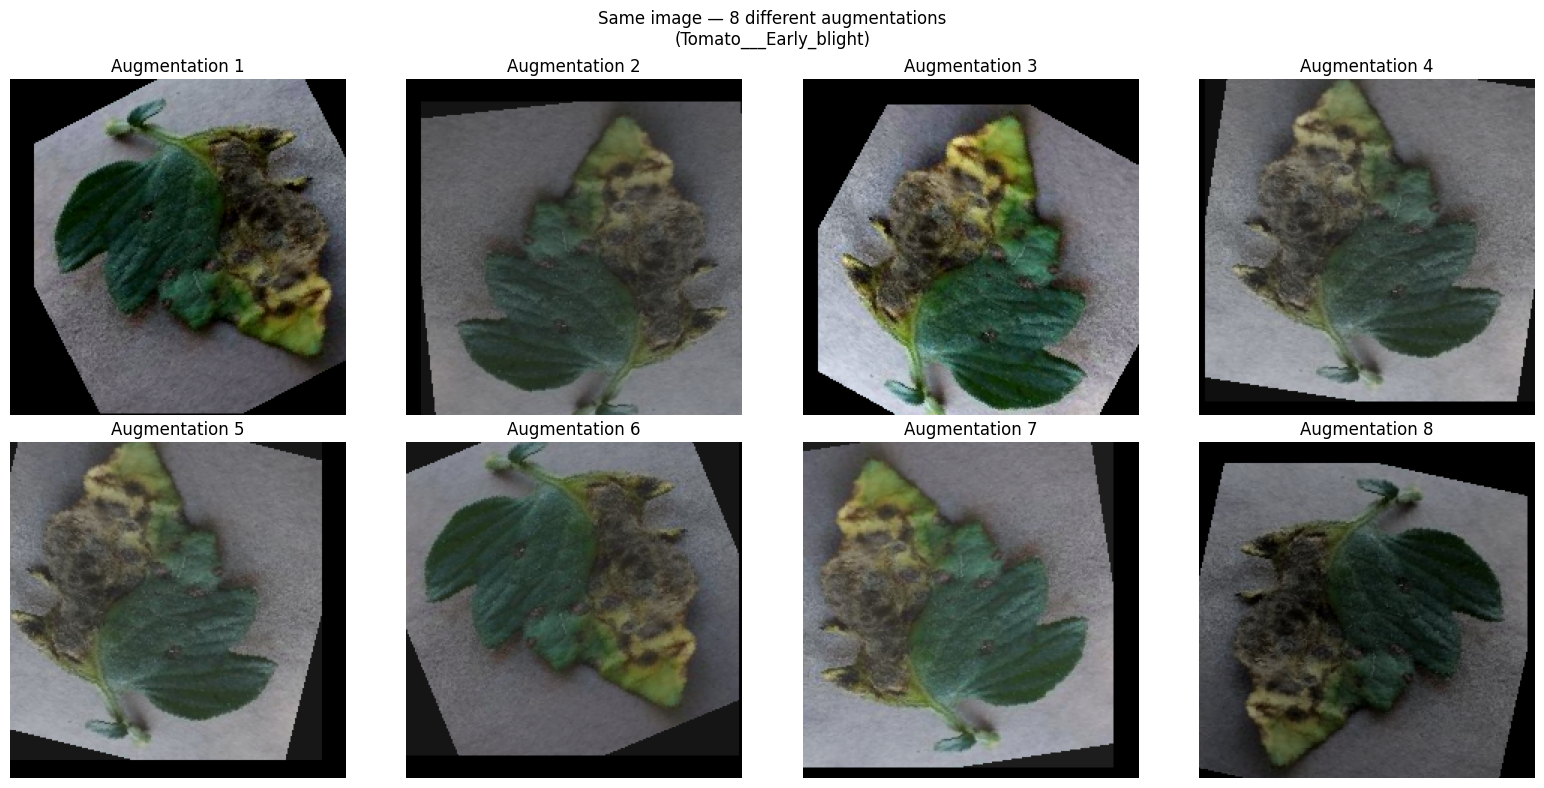

In [6]:
def visualize_augmentations(dataset_path, class_name='Tomato___Early_blight', num_versions=8):
    """
    Show the same image with different augmentations applied.
    """
    import os
    from PIL import Image

    # Load one original image
    class_path = os.path.join(dataset_path, class_name)
    img_file = os.listdir(class_path)[0]
    original_img = Image.open(os.path.join(class_path, img_file)).convert('RGB')

    # Apply training transforms multiple times
    train_tf, _ = get_transforms()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_versions):
        augmented = train_tf(original_img)

        # Denormalize for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = augmented * std + mean
        img_display = img_display.permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        axes[i].imshow(img_display)
        axes[i].set_title(f'Augmentation {i+1}')
        axes[i].axis('off')

    plt.suptitle(f'Same image — 8 different augmentations\n({class_name})', fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_augmentations(dataset_path)

## Model

In [7]:
import torch
import torch.nn as nn
from torchvision import models

class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()

        # Load EfficientNet-B3 pretrained on ImageNet
        self.backbone = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last 20 parameters for fine-tuning
        for param in list(self.backbone.parameters())[-20:]:
            param.requires_grad = True

        # Get the input featuresof the original classifier
        in_features = self.backbone.classifier[1].in_features
        print(f"EfficientNet-B3 feature vector size: {in_features}")

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [9]:
model = PlantDiseaseModel(num_classes=38)
model = model.to(device)
print("Model created successfully")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 224MB/s]


EfficientNet-B3 feature vector size: 1536
Model created successfully


In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")
print(f"Trainable %:          {100 * trainable_params / total_params:.1f}%")

Total parameters:     11,502,670
Trainable parameters: 3,645,062
Frozen parameters:    7,857,608
Trainable %:          31.7%


In [11]:
# Test forward pass with a dummy batch
dummy_input = torch.randn(4, 3, 224, 224).to(device)
with torch.no_grad():
    output = model(dummy_input)

print(f"\nInput shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output is logits for {output.shape[1]} classes")


Input shape:  torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 38])
Output is logits for 38 classes


In [12]:
print("Our custom classifier head:")
print(model.backbone.classifier)

print("\nFirst few layers of backbone (frozen):")
children = list(model.backbone.children())
for i, child in enumerate(children[:3]):
    print(f"  Layer {i}: {type(child).__name__}")

Our custom classifier head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1536, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=512, out_features=38, bias=True)
)

First few layers of backbone (frozen):
  Layer 0: Sequential
  Layer 1: AdaptiveAvgPool2d
  Layer 2: Sequential


# Training Loop

In [13]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import wandb
import os
from kaggle_secrets import UserSecretsClient

In [14]:
# Login to wandb
secret_value = UserSecretsClient().get_secret("WANDB_API_KEY")
wandb.login(key=secret_value)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: snrupendra (snrupendra-sardar-vallabhbhai-national-institute-of-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [15]:
def train_model(model, train_loader, val_loader, num_epochs=10, device='cuda', run_name='plant-disease'):
    
    # Loss function
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Optimizer — only trainable parameters
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4
    )
    
    # Learning rate scheduler
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # Track best model
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'
    
    # Initialize wandb run
    wandb.init(
        project="plant-disease-detection",
        name=run_name,
        config={
            "epochs": num_epochs,
            "batch_size": 32,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "architecture": "EfficientNet-B3",
            "dataset": "PlantVillage"
        }
    )
    
    print(f"Starting training for {num_epochs} epochs...")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        
        # ---- Training Phase ----
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            # Zero gradients from previous step
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            
            # Compute loss
            loss = criterion(outputs, labels)
            
            # Backward pass — compute gradients
            loss.backward()
            
            # Update weights
            optimizer.step()
            
            # Track metrics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            
            # Print progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                      f"Loss: {loss.item():.4f}")
        
        # ---- Validation Phase ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)
        
        # Compute epoch metrics
        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        
        # Log to wandb
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "learning_rate": current_lr
        })
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  LR: {current_lr:.6f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names
            }, best_model_path)
            print(f"  ✓ Best model saved! Val Acc: {val_acc:.2f}%")
        
        # Step the scheduler
        scheduler.step()
        print("-" * 60)
    
    wandb.finish()
    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.2f}%")
    return best_val_acc

In [16]:
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np

In [17]:
smoke_classes = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___healthy',
    'Tomato___Early_blight',
    'Tomato___healthy'
]

print("Setting up 5-class smoke test...")

# Load full dataset
train_tf, val_tf = get_transforms()
full_dataset = datasets.ImageFolder(dataset_path, transform=train_tf)

# Get original indices for our 5 classes
class_to_idx = full_dataset.class_to_idx
selected_original_indices = [class_to_idx[c] for c in smoke_classes]
print(f"Original class indices: {selected_original_indices}")

# Build label remapping: old index → new index (0-4)
label_remap = {old: new for new, old in enumerate(selected_original_indices)}
print(f"Label remap: {label_remap}")

# Custom dataset that remaps labels
class RemappedSubset(Dataset):
    def __init__(self, dataset, indices, label_remap):
        self.dataset = dataset
        self.indices = indices
        self.label_remap = label_remap

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        return image, self.label_remap[label]

# Filter to only selected class images
smoke_indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if label in selected_original_indices
]
print(f"Total images for smoke test: {len(smoke_indices)}")

# Split 80/20
smoke_train_size = int(0.8 * len(smoke_indices))
smoke_val_size = len(smoke_indices) - smoke_train_size

train_indices = smoke_indices[:smoke_train_size]
val_indices = smoke_indices[smoke_train_size:]

# Apply val transforms to val set
val_dataset = datasets.ImageFolder(dataset_path, transform=val_tf)

smoke_train_dataset = RemappedSubset(full_dataset, train_indices, label_remap)
smoke_val_dataset = RemappedSubset(val_dataset, val_indices, label_remap)

smoke_train_loader = DataLoader(smoke_train_dataset, batch_size=32, shuffle=True, num_workers=2)
smoke_val_loader = DataLoader(smoke_val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Smoke train batches: {len(smoke_train_loader)}")
print(f"Smoke val batches:   {len(smoke_val_loader)}")

# Verify labels are now 0-4
images, labels = next(iter(smoke_train_loader))
print(f"Label range in batch: min={labels.min().item()}, max={labels.max().item()}")
print(f"Unique labels in batch: {labels.unique().tolist()}")

# Create fresh model with 5 classes
smoke_model = PlantDiseaseModel(num_classes=5)
smoke_model = smoke_model.to(device)

# Train for 3 epochs
best_acc = train_model(
    smoke_model,
    smoke_train_loader,
    smoke_val_loader,
    num_epochs=3,
    device=device,
    run_name='smoke-test-5classes'
)

Setting up 5-class smoke test...
Original class indices: [0, 1, 3, 29, 37]
Label remap: {0: 0, 1: 1, 3: 2, 29: 3, 37: 4}
Total images for smoke test: 5487
Smoke train batches: 138
Smoke val batches:   35
Label range in batch: min=0, max=4
Unique labels in batch: [0, 1, 2, 3, 4]
EfficientNet-B3 feature vector size: 1536


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260624_044053-hiwq3szc
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run smoke-test-5classes
wandb: ⭐️ View project at https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection
wandb: 🚀 View run at https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection/runs/hiwq3szc


Starting training for 3 epochs...
------------------------------------------------------------
  Epoch 1 | Batch 50/138 | Loss: 0.5185
  Epoch 1 | Batch 100/138 | Loss: 0.5113

Epoch 1/3
  Train Loss: 0.6178 | Train Acc: 91.09%
  Val Loss:   0.4314 | Val Acc:   99.82%
  LR: 0.001000
  ✓ Best model saved! Val Acc: 99.82%
------------------------------------------------------------
  Epoch 2 | Batch 50/138 | Loss: 0.4829
  Epoch 2 | Batch 100/138 | Loss: 0.4435

Epoch 2/3
  Train Loss: 0.4808 | Train Acc: 97.88%
  Val Loss:   0.4261 | Val Acc:   99.64%
  LR: 0.000750
------------------------------------------------------------
  Epoch 3 | Batch 50/138 | Loss: 0.4634
  Epoch 3 | Batch 100/138 | Loss: 0.4293


wandb: updating run metadata



Epoch 3/3
  Train Loss: 0.4600 | Train Acc: 98.22%
  Val Loss:   0.4449 | Val Acc:   98.72%
  LR: 0.000250
------------------------------------------------------------


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 2-2, summary, console lines 21-26
wandb: 
wandb: Run history:
wandb:         epoch ▁▅█
wandb: learning_rate █▆▁
wandb:     train_acc ▁██
wandb:    train_loss █▂▁
wandb:       val_acc █▇▁
wandb:      val_loss ▃▁█
wandb: 
wandb: Run summary:
wandb:         epoch 3
wandb: learning_rate 0.00025
wandb:     train_acc 98.22283
wandb:    train_loss 0.46005
wandb:       val_acc 98.72495
wandb:      val_loss 0.44488
wandb: 
wandb: 🚀 View run smoke-test-5classes at: https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection/runs/hiwq3szc
wandb: ⭐️ View project at: https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260624_044053-hiwq3szc/logs



Training complete. Best Val Acc: 99.82%


## Full Training

In [18]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import wandb
import os
from kaggle_secrets import UserSecretsClient

In [19]:
def train_full(model, train_loader, val_loader, class_names,
               num_epochs=20, device='cuda'):

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4
    )

    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0
    best_model_path = 'best_model.pth'
    checkpoint_path = 'checkpoint_latest.pth'

    # Initialize wandb
    secret_value = UserSecretsClient().get_secret("WANDB_API_KEY")
    wandb.login(key=secret_value)

    wandb.init(
        project="plant-disease-detection",
        name="full-38class-efficientnet-b3",
        config={
            "epochs": num_epochs,
            "batch_size": 32,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "architecture": "EfficientNet-B3",
            "num_classes": 38,
            "dataset": "PlantVillage",
            "optimizer": "AdamW",
            "scheduler": "CosineAnnealingLR",
            "label_smoothing": 0.1,
            "gradient_clip": 1.0
        }
    )

    print("Starting full 38-class training...")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches:   {len(val_loader)}")
    print("-" * 60)

    for epoch in range(num_epochs):

        # ---- Training Phase ----
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)

            # Progress every 100 batches
            if (batch_idx + 1) % 100 == 0:
                batch_acc = 100.0 * train_correct / train_total
                print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                      f"Loss: {loss.item():.4f} | Running Acc: {batch_acc:.2f}%")

        # ---- Validation Phase ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Compute metrics
        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]

        # Log to wandb
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "learning_rate": current_lr
        })

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  LR: {current_lr:.6f}")

        # Save latest checkpoint every epoch
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'best_val_acc': best_val_acc,
            'class_names': class_names
        }, checkpoint_path)
        print(f"  Checkpoint saved (epoch {epoch+1})")

        # Save best model separately
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names
            }, best_model_path)
            print(f"  ✓ Best model saved! Val Acc: {val_acc:.2f}%")

        scheduler.step()
        print("-" * 60)

    wandb.finish()
    print(f"\nTraining complete!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    return best_val_acc

In [20]:
full_model = PlantDiseaseModel(num_classes=38)
full_model = full_model.to(device)

print(f"Model on device: {next(full_model.parameters()).device}")
print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Label range: min={labels.min()}, max={labels.max().item()}")

# Full Training
best_acc = train_full(
    full_model,
    train_loader,
    val_loader,
    class_names,
    num_epochs=20,
    device=device
)

EfficientNet-B3 feature vector size: 1536
Model on device: cuda:0
Train loader batches: 1358
Val loader batches: 170


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Batch shape: torch.Size([32, 3, 224, 224])
Label range: min=0, max=37


wandb: setting up run 5c3een6o
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260624_044217-5c3een6o
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run full-38class-efficientnet-b3
wandb: ⭐️ View project at https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection
wandb: 🚀 View run at https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection/runs/5c3een6o


Starting full 38-class training...
Train batches: 1358
Val batches:   170
------------------------------------------------------------
  Epoch 1 | Batch 100/1358 | Loss: 1.4516 | Running Acc: 60.09%
  Epoch 1 | Batch 200/1358 | Loss: 1.1103 | Running Acc: 71.95%
  Epoch 1 | Batch 300/1358 | Loss: 1.0541 | Running Acc: 77.27%
  Epoch 1 | Batch 400/1358 | Loss: 1.0590 | Running Acc: 80.40%
  Epoch 1 | Batch 500/1358 | Loss: 0.9414 | Running Acc: 82.47%
  Epoch 1 | Batch 600/1358 | Loss: 0.9924 | Running Acc: 83.86%
  Epoch 1 | Batch 700/1358 | Loss: 0.8847 | Running Acc: 85.21%
  Epoch 1 | Batch 800/1358 | Loss: 1.0885 | Running Acc: 86.21%
  Epoch 1 | Batch 900/1358 | Loss: 0.9949 | Running Acc: 86.94%
  Epoch 1 | Batch 1000/1358 | Loss: 0.8568 | Running Acc: 87.63%
  Epoch 1 | Batch 1100/1358 | Loss: 0.8464 | Running Acc: 88.24%
  Epoch 1 | Batch 1200/1358 | Loss: 0.8880 | Running Acc: 88.74%
  Epoch 1 | Batch 1300/1358 | Loss: 0.8919 | Running Acc: 89.21%

Epoch 1/20
  Train Loss: 1.0

wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading output.log
wandb: uploading history steps 19-19, summary, console lines 408-414
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ████▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁
wandb:     train_acc ▁▆▆▇▇▇▇▇████████████
wandb:    train_loss █▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▅▅▆▆▆▆▆▆▆▇█████████
wandb:      val_loss █▆▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:         epoch 20
wandb: learning_rate 1e-05
wandb:     train_acc 99.78823
wandb:    train_loss 0.70742
wandb:       val_acc 99.07919
wandb:      val_loss 0.70512
wandb: 
wandb: 🚀 View run full-38class-efficientnet-b3 at: https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection/runs/5c3een6o
wandb: ⭐️ View project at: https://wandb.ai/snrupendra-sardar-vallabhbhai-national-institute-of-tech/plant-disease-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 


Training complete!
Best Validation Accuracy: 99.12%
